In [28]:
# 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
# 2. Load Dataset
matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")

matches.head()
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [30]:
# 3. Basic Info
print(matches.shape)
print(deliveries.shape)

matches.info()
deliveries.info()

matches.isnull().sum()
deliveries.isnull().sum()

(756, 18)
(179078, 21)
<class 'pandas.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   id               756 non-null    int64
 1   season           756 non-null    int64
 2   city             749 non-null    str  
 3   date             756 non-null    str  
 4   team1            756 non-null    str  
 5   team2            756 non-null    str  
 6   toss_winner      756 non-null    str  
 7   toss_decision    756 non-null    str  
 8   result           756 non-null    str  
 9   dl_applied       756 non-null    int64
 10  winner           752 non-null    str  
 11  win_by_runs      756 non-null    int64
 12  win_by_wickets   756 non-null    int64
 13  player_of_match  752 non-null    str  
 14  venue            756 non-null    str  
 15  umpire1          754 non-null    str  
 16  umpire2          754 non-null    str  
 17  umpire3          119 non-null    str  
dty

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batsman                  0
non_striker              0
bowler                   0
is_super_over            0
wide_runs                0
bye_runs                 0
legbye_runs              0
noball_runs              0
penalty_runs             0
batsman_runs             0
extra_runs               0
total_runs               0
player_dismissed    170244
dismissal_kind      170244
fielder             172630
dtype: int64

In [31]:
# 4. Data Cleaning
# Convert date
matches['date'] = pd.to_datetime(matches['date'], errors='coerce')

# Extract Year
matches['year'] = matches['date'].dt.year

# Drop duplicates
matches.drop_duplicates(inplace=True)
deliveries.drop_duplicates(inplace=True)

In [32]:
# 5. Feature Engineering
# Total Runs per Match
total_runs = deliveries.groupby('match_id')['total_runs'].sum().reset_index()
total_runs.columns = ['match_id', 'total_runs']

matches = matches.merge(total_runs, left_on='id', right_on='match_id')

In [33]:
# Strike Rate of Batsman
batsman_stats = deliveries.groupby('batsman').agg({
    'batsman_runs': 'sum',
    'ball': 'count'
}).reset_index()

batsman_stats['strike_rate'] = (batsman_stats['batsman_runs'] / batsman_stats['ball']) * 100

In [34]:
# Top Bowlers (Wickets)
dismissals = deliveries[deliveries['dismissal_kind'].notnull()]

top_bowlers = dismissals['bowler'].value_counts().head(10)

In [35]:
# 6. Exploratory Data Analysis (EDA)
# Top Teams by Wins
matches['winner'].value_counts().head(10)

winner
Mumbai Indians                 109
Chennai Super Kings            100
Kolkata Knight Riders           92
Royal Challengers Bangalore     84
Kings XI Punjab                 82
Rajasthan Royals                75
Delhi Daredevils                67
Sunrisers Hyderabad             58
Deccan Chargers                 29
Gujarat Lions                   13
Name: count, dtype: int64

In [36]:
# Matches per Season
matches.groupby('year')['id'].count()

year
2008.0    58
2009.0    57
2010.0    60
2011.0    73
2012.0    74
2013.0    76
2014.0    60
2015.0    59
2016.0    60
2017.0    59
Name: id, dtype: int64

In [37]:
# Top Cities Hosting Matches
matches['city'].value_counts().head(10)

city
Mumbai        101
Kolkata        77
Delhi          74
Bangalore      66
Hyderabad      64
Chennai        57
Jaipur         47
Chandigarh     46
Pune           38
Durban         15
Name: count, dtype: int64

In [38]:
# Most Runs by Batsman
deliveries.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(10)

batsman
V Kohli           5434
SK Raina          5415
RG Sharma         4914
DA Warner         4741
S Dhawan          4631
CH Gayle          4560
MS Dhoni          4477
RV Uthappa        4444
AB de Villiers    4428
G Gambhir         4223
Name: batsman_runs, dtype: int64

In [39]:
# Most Sixes
deliveries[deliveries['batsman_runs'] == 6]['batsman'].value_counts().head(10)

batsman
CH Gayle          327
AB de Villiers    214
MS Dhoni          207
SK Raina          195
RG Sharma         194
V Kohli           191
DA Warner         181
SR Watson         177
KA Pollard        175
YK Pathan         161
Name: count, dtype: int64

In [40]:
# 7. Filtering
# High scoring matches
matches[matches['total_runs'] > 200]

# Matches won by big margin
matches[matches['win_by_runs'] > 50]

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,...,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,year,match_id,total_runs
8,9,2017,Pune,2017-04-11,Delhi Daredevils,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,...,97,0,SV Samson,Maharashtra Cricket Association Stadium,AY Dandekar,S Ravi,NaN,2017.0,9,313
14,15,2017,Delhi,2017-04-15,Delhi Daredevils,Kings XI Punjab,Delhi Daredevils,bat,normal,0,...,51,0,CJ Anderson,Feroz Shah Kotla,YC Barde,Nitin Menon,NaN,2017.0,15,325
26,27,2017,Kolkata,2017-04-23,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,...,82,0,NM Coulter-Nile,Eden Gardens,CB Gaffaney,CK Nandan,NaN,2017.0,27,180
32,33,2017,Pune,2017-04-29,Rising Pune Supergiant,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,...,61,0,LH Ferguson,Maharashtra Cricket Association Stadium,KN Ananthapadmanabhan,M Erasmus,NaN,2017.0,33,253
43,44,2017,Delhi,2017-05-06,Mumbai Indians,Delhi Daredevils,Delhi Daredevils,field,normal,0,...,146,0,LMP Simmons,Feroz Shah Kotla,Nitin Menon,CK Nandan,NaN,2017.0,44,278
59,60,2008,Bangalore,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,...,140,0,BB McCullum,M Chinnaswamy Stadium,Asad Rauf,RE Koertzen,NaN,2008.0,60,304
68,69,2008,Chandigarh,2008-04-25,Kings XI Punjab,Mumbai Indians,Mumbai Indians,field,normal,0,...,66,0,KC Sangakkara,"Punjab Cricket Association Stadium, Mohali",Aleem Dar,AM Saheba,NaN,2008.0,69,298
100,101,2008,Jaipur,2008-05-17,Rajasthan Royals,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,...,65,0,GC Smith,Sawai Mansingh Stadium,BF Bowden,SL Shastri,NaN,2008.0,101,329
114,115,2008,Mumbai,2008-05-30,Rajasthan Royals,Delhi Daredevils,Delhi Daredevils,field,normal,0,...,105,0,SR Watson,Wankhede Stadium,BF Bowden,RE Koertzen,NaN,2008.0,115,279
118,119,2009,Cape Town,2009-04-18,Royal Challengers Bangalore,Rajasthan Royals,Royal Challengers Bangalore,bat,normal,0,...,75,0,R Dravid,Newlands,BR Doctrove,RB Tiffin,NaN,2009.0,119,191


In [ ]:
# 8. Player Classification 
def player_type(runs):
    if runs > 5000:
        return "Legend"
    elif runs > 3000:
        return "Pro"
    else:
        return "Average"

batsman_stats['Player_Type'] = batsman_stats['batsman_runs'].apply(player_type)

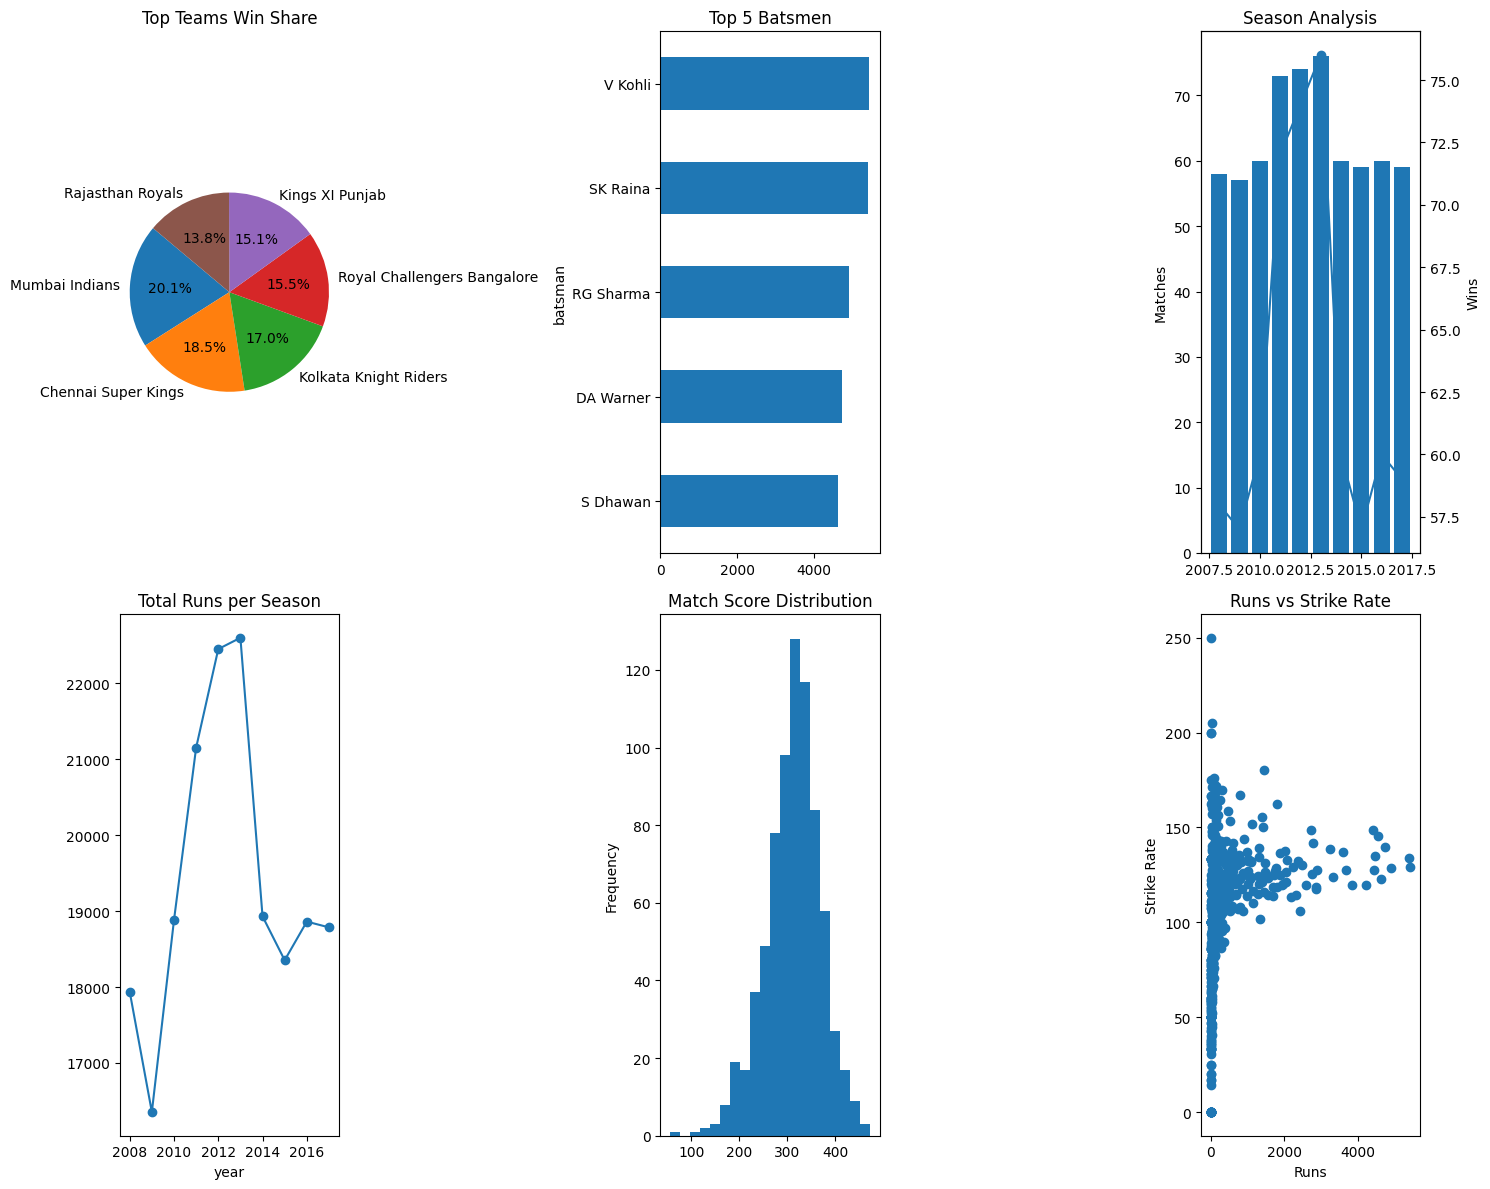

In [ ]:
# 9. Visualization 
plt.figure(figsize=(15, 12))
# 1️.Pie Chart → Team Wins Share
plt.subplot(2, 3, 1)

team_wins = matches['winner'].value_counts().head(6)

plt.pie(team_wins, labels=team_wins.index, autopct='%1.1f%%', startangle=140)
plt.title("Top Teams Win Share")
plt.axis('equal')

# 2.Bar → Top 5 Batsmen
plt.subplot(2, 3, 2)

top_batsmen = deliveries.groupby('batsman')['batsman_runs'].sum().sort_values().tail(5)

top_batsmen.plot(kind='barh')
plt.title("Top 5 Batsmen")

# 3.Bar + Line → Matches vs Wins per Season
plt.subplot(2, 3, 3)

season_matches = matches.groupby('year')['id'].count()
season_wins = matches.groupby('year')['winner'].count()

ax1 = plt.gca()

ax1.bar(season_matches.index, season_matches)
ax1.set_ylabel("Matches")

ax2 = ax1.twinx()
ax2.plot(season_wins.index, season_wins, marker='o')
ax2.set_ylabel("Wins")

plt.title("Season Analysis")

# 4.Line → Runs per Season
plt.subplot(2, 3, 4)

season_runs = matches.groupby('year')['total_runs'].sum()
season_runs.plot(marker='o')

plt.title("Total Runs per Season")

# 5.Histogram → Runs Distribution
plt.subplot(2, 3, 5)

matches['total_runs'].plot(kind='hist', bins=20)
plt.title("Match Score Distribution")

#6.Scatter → Strike Rate vs Runs
plt.subplot(2, 3, 6)

plt.scatter(batsman_stats['batsman_runs'], batsman_stats['strike_rate'])
plt.title("Runs vs Strike Rate")
plt.xlabel("Runs")
plt.ylabel("Strike Rate")

# Final
plt.tight_layout()
plt.show()

